# Gazetteer Telemetry Evaluation: Legacy vs Modern DUUI-Py

This report focuses only on telemetry-measured evaluation metrics:

- request latency and tail latency (`p50`, `p90`, `p95`, `p99`)
- request throughput
- request counts and errors
- process/system CPU and memory resource metrics
- component processing-time telemetry

Pair: `gazetteer-legacy-lua` vs `gazetteer-msgpack-lua`.
Configs: `plain-de` and `virus-skipgram`.

The request metrics below use only telemetry events with `duui.scope == request` so scoped duplicates (`global`, `component`) do not inflate the distributions.

In [11]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.dpi"] = 130
plt.rcParams["savefig.dpi"] = 180
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["font.family"] = "DejaVu Sans"

RESULT_PATH = next(path for path in [
    Path("gazetteer_legacy_vs_msgpack_evaluation_results.json"),
    Path("duui-py/examples/gazetteer_legacy_vs_msgpack_evaluation_results.json"),
] if path.exists())

data = json.loads(RESULT_PATH.read_text(encoding="utf-8"))

def event_value(event):
    points = event.get("data_points") or []
    if not points:
        return np.nan
    return points[0].get("as_double", np.nan)

def event_attrs(event):
    attrs = dict(event.get("attributes") or {})
    points = event.get("data_points") or []
    if points:
        attrs.update(points[0].get("attributes") or {})
    return attrs

metric_rows = []
summary_rows = []
for config, run in data["config_runs"].items():
    for event in run["telemetry_events"]:
        attrs = event_attrs(event)
        component_id = attrs.get("duui.component_id", "")
        component = "legacy" if component_id.endswith("legacy") else "modern" if component_id.endswith("modern") else component_id
        artifact = attrs.get("duui.artifact_id")
        if event.get("type") == "metric":
            metric_rows.append({
                "config": config,
                "type": event.get("type"),
                "name": event.get("name"),
                "unit": event.get("unit"),
                "metric_type": event.get("metric_type"),
                "value": event_value(event),
                "component_id": component_id,
                "component": component,
                "artifact_id": artifact,
                "request_id": attrs.get("duui.request_id"),
                "scope": attrs.get("duui.scope") or attrs.get("scope"),
                "category": attrs.get("duui.metric.category"),
                "status_code": attrs.get("status_code"),
            })
        elif event.get("type") == "summary":
            summary_rows.append({
                "config": config,
                "component": component,
                "artifact_id": artifact,
                "request_id": attrs.get("duui.request_id"),
                "status_code": attrs.get("status_code"),
                "duration_ms": float(attrs.get("duration_ms", "nan")),
            })

metrics = pd.DataFrame(metric_rows)
summaries = pd.DataFrame(summary_rows)

# Drop warmup rows from measured analysis.
metrics_measured = metrics[metrics["artifact_id"].ne("warmup")].copy()
summaries_measured = summaries[summaries["artifact_id"].ne("warmup")].copy()

request_metrics = metrics_measured[
    metrics_measured["name"].isin(["duui.request.duration", "duui.request.throughput", "duui.request.count", "duui.request.errors"])
    & metrics_measured["scope"].eq("request")
].copy()

latency = request_metrics[request_metrics["name"].eq("duui.request.duration")].copy()
throughput = request_metrics[request_metrics["name"].eq("duui.request.throughput")].copy()
counts = request_metrics[request_metrics["name"].eq("duui.request.count")].copy()
errors = request_metrics[request_metrics["name"].eq("duui.request.errors")].copy()

resource_metrics = metrics_measured[
    metrics_measured["name"].str.startswith(("process.", "system."), na=False)
].copy()
processing_metrics = metrics_measured[
    metrics_measured["name"].isin(["gazetteer_processing_ms", "gazetteer_legacy_processing_ms"])
].copy()

print(f"telemetry metric events: {len(metrics):,}")
print(f"measured request latency samples: {len(latency)}")
print(f"measured throughput samples: {len(throughput)}")
print(f"measured resource samples: {len(resource_metrics)}")
metrics_measured[["config", "component", "artifact_id", "name", "scope", "value", "unit"]].head()

telemetry metric events: 1,344
measured request latency samples: 24
measured throughput samples: 24
measured resource samples: 816


,config,component,artifact_id,name,scope,value,unit
96,plain-de,legacy,3713534-chunk-1,gazetteer_legacy_matches,NaN,1.00,count
97,plain-de,legacy,3713534-chunk-1,gazetteer_legacy_processing_ms,NaN,3.00,milliseconds
98,plain-de,legacy,3713534-chunk-1,process.cpu.utilization,process,0.00,percent
99,plain-de,legacy,3713534-chunk-1,process.cpu.time.user,process,0.96,seconds
100,plain-de,legacy,3713534-chunk-1,process.cpu.time.system,process,0.18,seconds


## Request Latency: Central Tendency and Tails

Tail latency matters more than the average for pipeline behavior. The table and plot use telemetry `duui.request.duration` at request scope only.

In [12]:
def q(series, quantile):
    return float(series.quantile(quantile))

latency_stats = (
    latency.groupby(["config", "component"])["value"]
    .agg(
        samples="count",
        mean_ms="mean",
        min_ms="min",
        p50_ms="median",
        p90_ms=lambda s: q(s, 0.90),
        p95_ms=lambda s: q(s, 0.95),
        p99_ms=lambda s: q(s, 0.99),
        max_ms="max",
    )
    .reset_index()
)
for col in latency_stats.columns:
    if col.endswith("_ms"):
        latency_stats[col] = latency_stats[col].round(2)
latency_stats

,config,component,samples,mean_ms,min_ms,p50_ms,p90_ms,p95_ms,p99_ms,max_ms
0,plain-de,legacy,6,6.39,5.19,6.39,7.44,7.58,7.70,7.73
1,plain-de,modern,6,6.35,5.33,6.31,7.07,7.31,7.50,7.54
2,virus-skipgram,legacy,6,7.08,6.01,6.72,8.40,8.41,8.42,8.42
3,virus-skipgram,modern,6,7.47,6.43,7.39,8.53,8.57,8.60,8.61


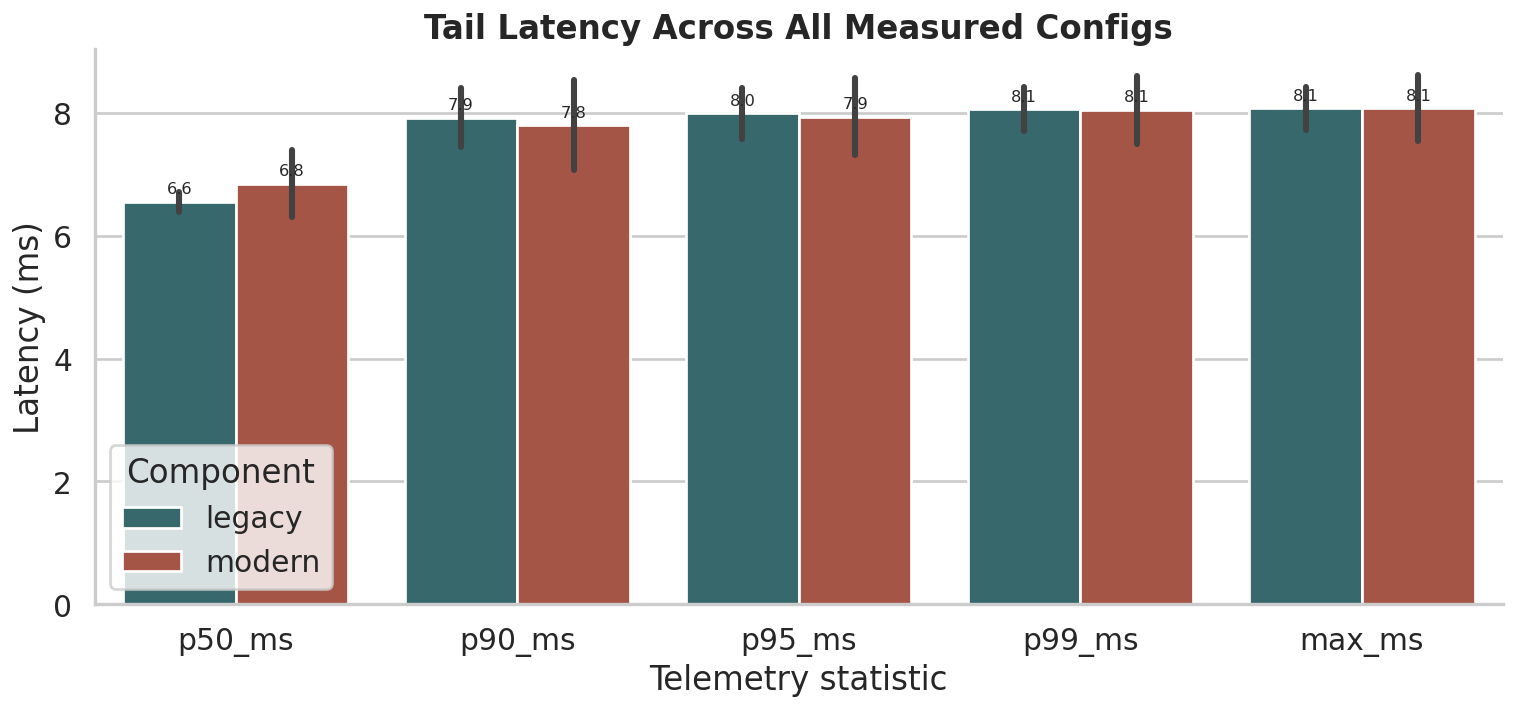

In [13]:
tail_df = latency_stats.melt(
    id_vars=["config", "component"],
    value_vars=["p50_ms", "p90_ms", "p95_ms", "p99_ms", "max_ms"],
    var_name="stat",
    value_name="latency_ms",
)

fig, ax = plt.subplots(figsize=(12, 5.8))
sns.barplot(
    data=tail_df,
    x="stat",
    y="latency_ms",
    hue="component",
    palette={"legacy": "#2f6f73", "modern": "#b44a36"},
    ax=ax,
)
ax.set_title("Tail Latency Across All Measured Configs")
ax.set_xlabel("Telemetry statistic")
ax.set_ylabel("Latency (ms)")
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f", padding=3, fontsize=9)
ax.legend(title="Component")
sns.despine()
plt.tight_layout()

/tmp/ipykernel_214475/3376853239.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


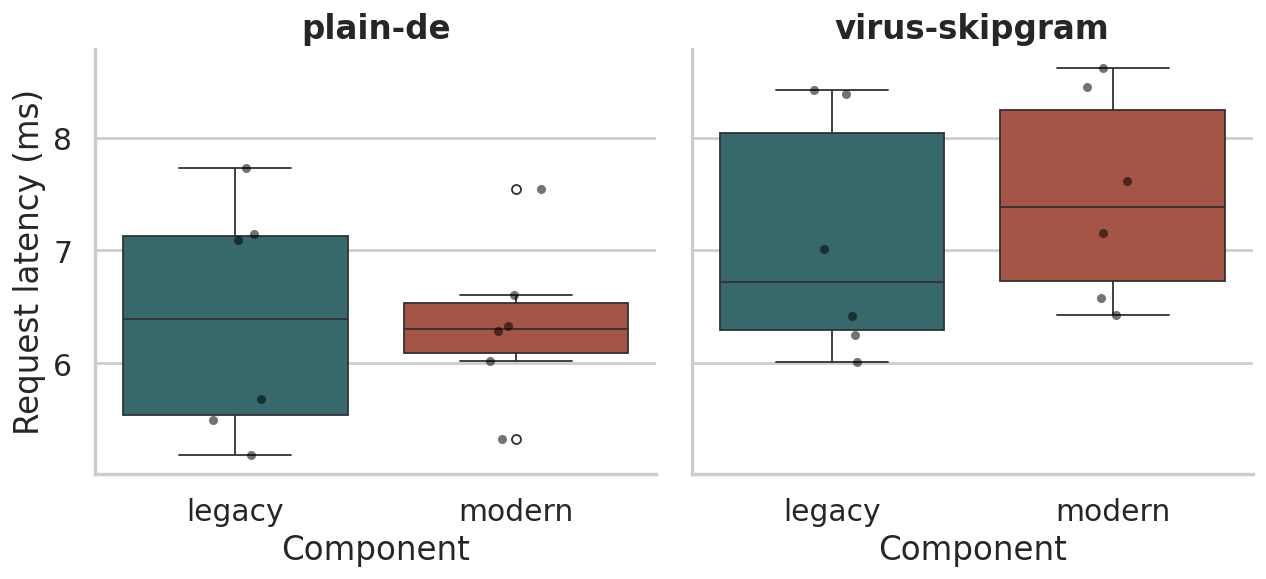

In [14]:
g = sns.catplot(
    data=latency,
    x="component",
    y="value",
    col="config",
    kind="box",
    height=4.8,
    aspect=1.05,
    palette={"legacy": "#2f6f73", "modern": "#b44a36"},
    showfliers=True,
)
g.set_axis_labels("Component", "Request latency (ms)")
g.set_titles("{col_name}")
for ax in g.axes.flat:
    sns.stripplot(data=latency[latency["config"].eq(ax.get_title())], x="component", y="value", color="black", alpha=.55, size=5, ax=ax)
    ax.set_title(ax.get_title(), fontweight="bold")
plt.tight_layout()

## Per-Document Request Latency

This keeps the view tied to request artifacts: each point is one document chunk measured by telemetry.

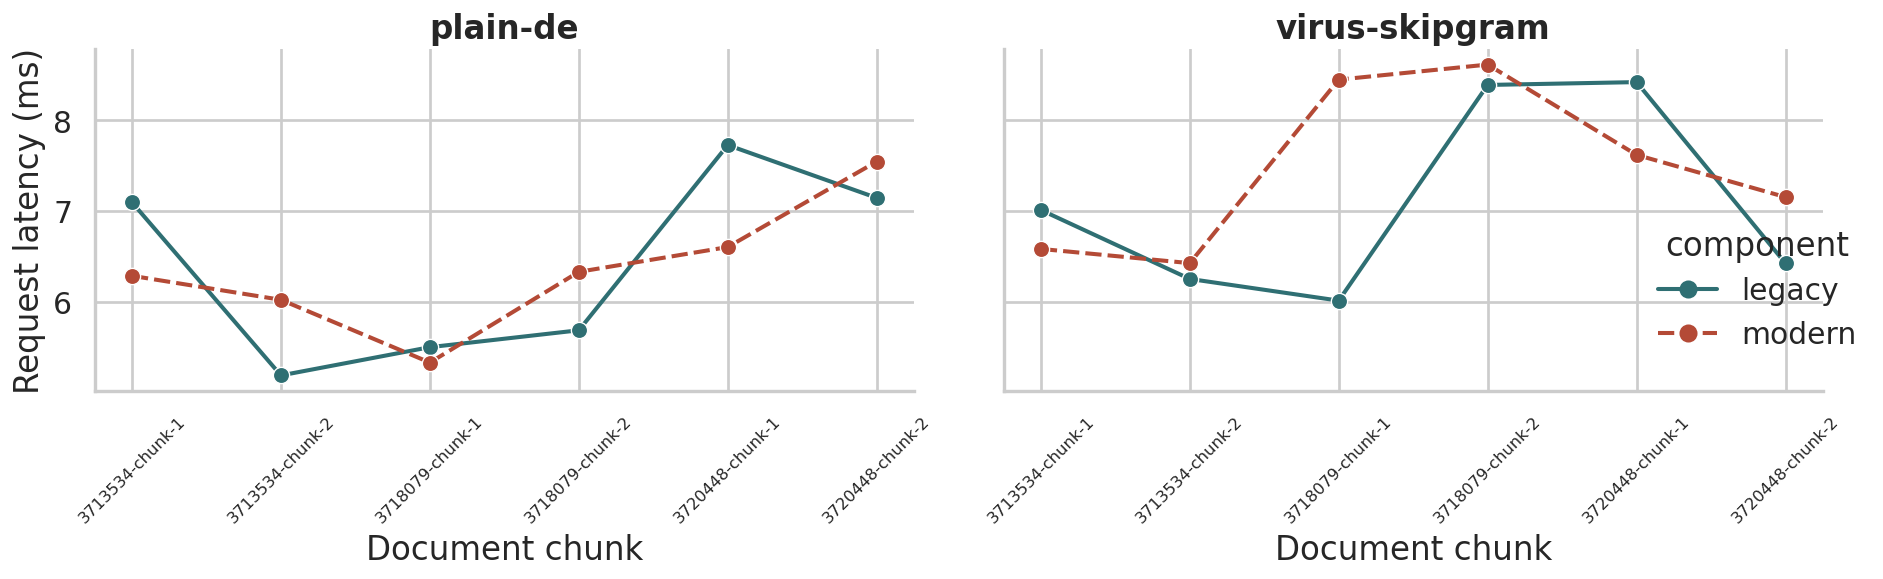

In [15]:
g = sns.relplot(
    data=latency,
    x="artifact_id",
    y="value",
    hue="component",
    style="component",
    col="config",
    kind="line",
    marker="o",
    height=4.8,
    aspect=1.35,
    palette={"legacy": "#2f6f73", "modern": "#b44a36"},
)
g.set_axis_labels("Document chunk", "Request latency (ms)")
g.set_titles("{col_name}")
for ax in g.axes.flat:
    ax.tick_params(axis="x", rotation=45, labelsize=9)
    ax.set_title(ax.get_title(), fontweight="bold")
plt.tight_layout()

## Throughput

Telemetry `duui.request.throughput` reports the rolling aggregate at request scope. This plot shows the request-scope samples by component and config.

,config,component,samples,mean_rps,p50_rps,p95_rps,max_rps
0,plain-de,legacy,6,1000.00,1000.0,1000.0,1000.0
1,plain-de,modern,6,999.67,1000.0,1000.0,1000.0
2,virus-skipgram,legacy,6,947.28,1000.0,1000.0,1000.0
3,virus-skipgram,modern,6,997.27,1000.0,1000.0,1000.0


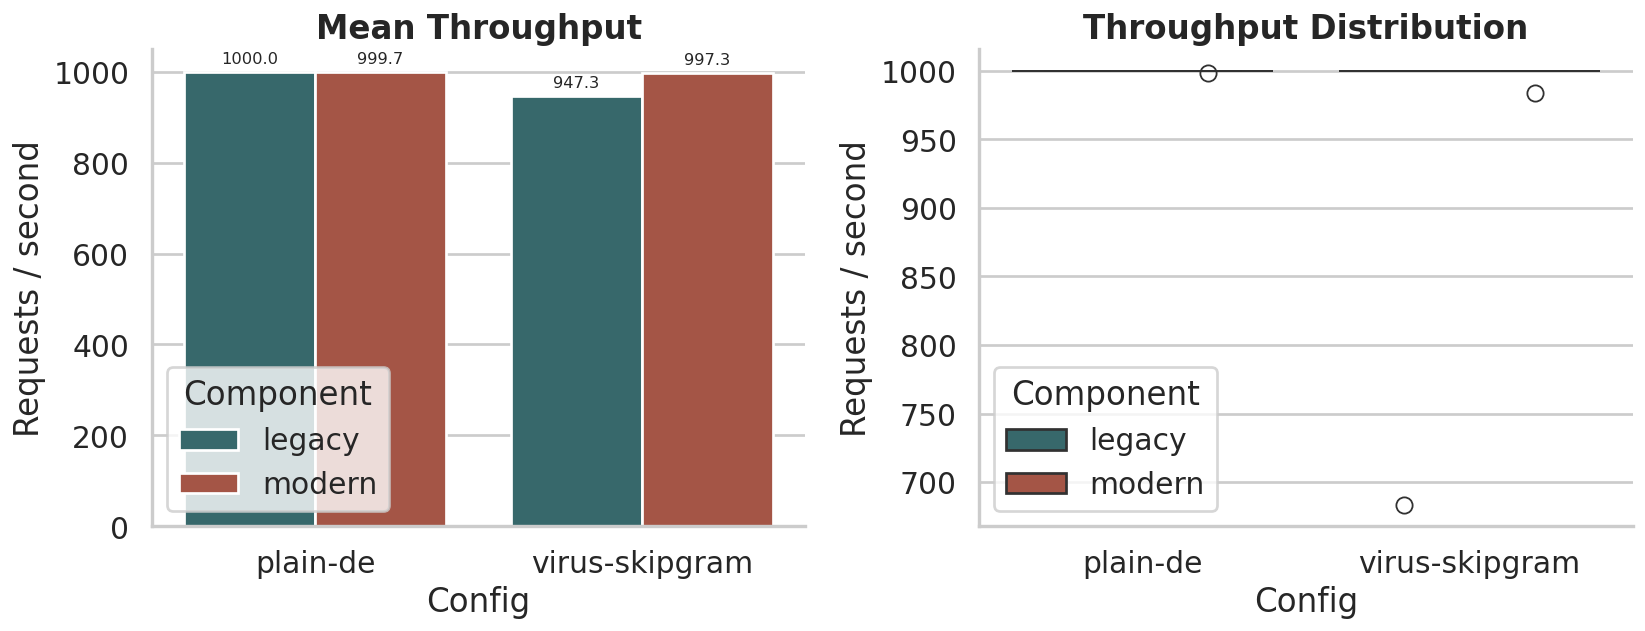

In [16]:
throughput_stats = (
    throughput.groupby(["config", "component"])["value"]
    .agg(samples="count", mean_rps="mean", p50_rps="median", p95_rps=lambda s: q(s, .95), max_rps="max")
    .reset_index()
)
for col in ["mean_rps", "p50_rps", "p95_rps", "max_rps"]:
    throughput_stats[col] = throughput_stats[col].round(2)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))
sns.barplot(data=throughput_stats, x="config", y="mean_rps", hue="component", palette={"legacy": "#2f6f73", "modern": "#b44a36"}, ax=axes[0])
axes[0].set_title("Mean Throughput")
axes[0].set_xlabel("Config")
axes[0].set_ylabel("Requests / second")
for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%.1f", padding=3, fontsize=9)

sns.boxplot(data=throughput, x="config", y="value", hue="component", palette={"legacy": "#2f6f73", "modern": "#b44a36"}, ax=axes[1])
axes[1].set_title("Throughput Distribution")
axes[1].set_xlabel("Config")
axes[1].set_ylabel("Requests / second")
for ax in axes:
    ax.legend(title="Component")
sns.despine()
plt.tight_layout()
throughput_stats

## Request Counts and Errors

This is the simplest telemetry sanity check: each measured artifact should produce request-count metrics, and error metrics should remain zero/absent.

,config,component,request_count_metric_sum,error_count_metric_sum
0,plain-de,legacy,6.0,0.0
1,plain-de,modern,6.0,0.0
2,virus-skipgram,legacy,6.0,0.0
3,virus-skipgram,modern,6.0,0.0


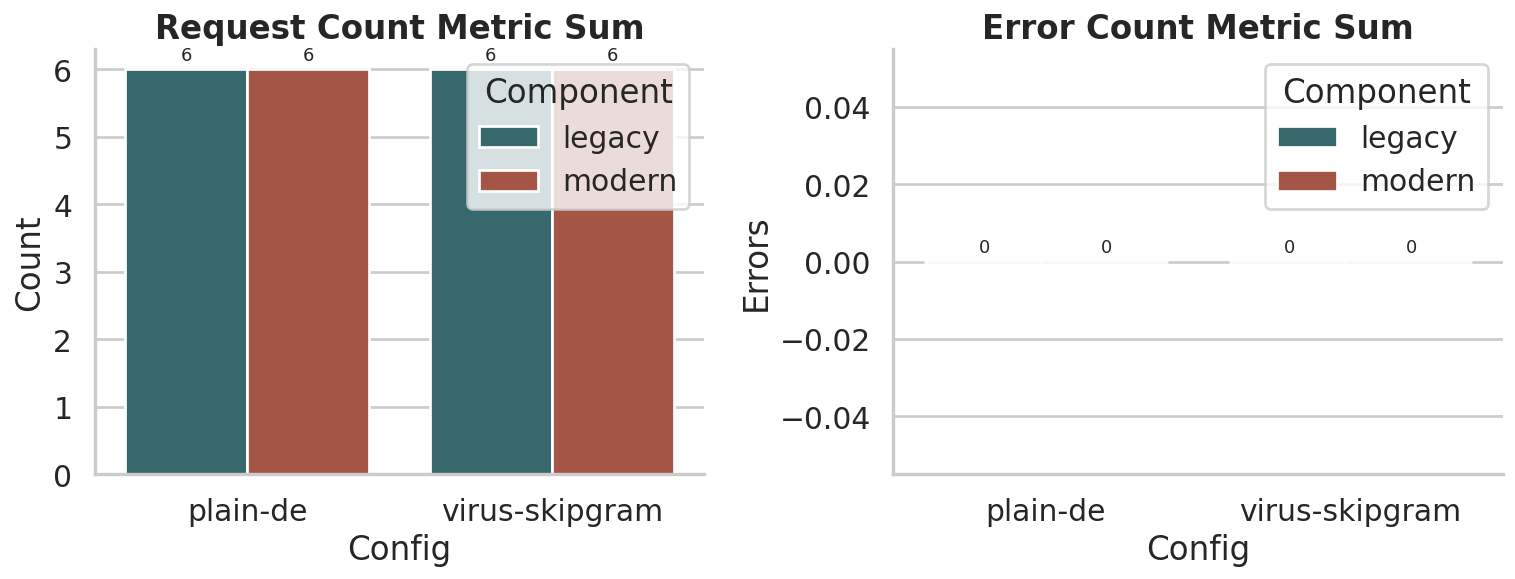

In [17]:
count_summary = counts.groupby(["config", "component"])["value"].sum().reset_index(name="request_count_metric_sum")
error_summary = errors.groupby(["config", "component"])["value"].sum().reset_index(name="error_count_metric_sum")
request_health = count_summary.merge(error_summary, on=["config", "component"], how="left").fillna({"error_count_metric_sum": 0})

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
sns.barplot(data=request_health, x="config", y="request_count_metric_sum", hue="component", palette={"legacy": "#2f6f73", "modern": "#b44a36"}, ax=axes[0])
axes[0].set_title("Request Count Metric Sum")
axes[0].set_ylabel("Count")
axes[0].set_xlabel("Config")
sns.barplot(data=request_health, x="config", y="error_count_metric_sum", hue="component", palette={"legacy": "#2f6f73", "modern": "#b44a36"}, ax=axes[1])
axes[1].set_title("Error Count Metric Sum")
axes[1].set_ylabel("Errors")
axes[1].set_xlabel("Config")
for ax in axes:
    for container in ax.containers:
        ax.bar_label(container, fmt="%.0f", padding=3, fontsize=10)
    ax.legend(title="Component")
sns.despine()
plt.tight_layout()
request_health

## Process CPU and Memory

Resource metrics are captured from telemetry events emitted around each request. These are process-level samples from the Python annotator process, not container-level cgroup measurements.

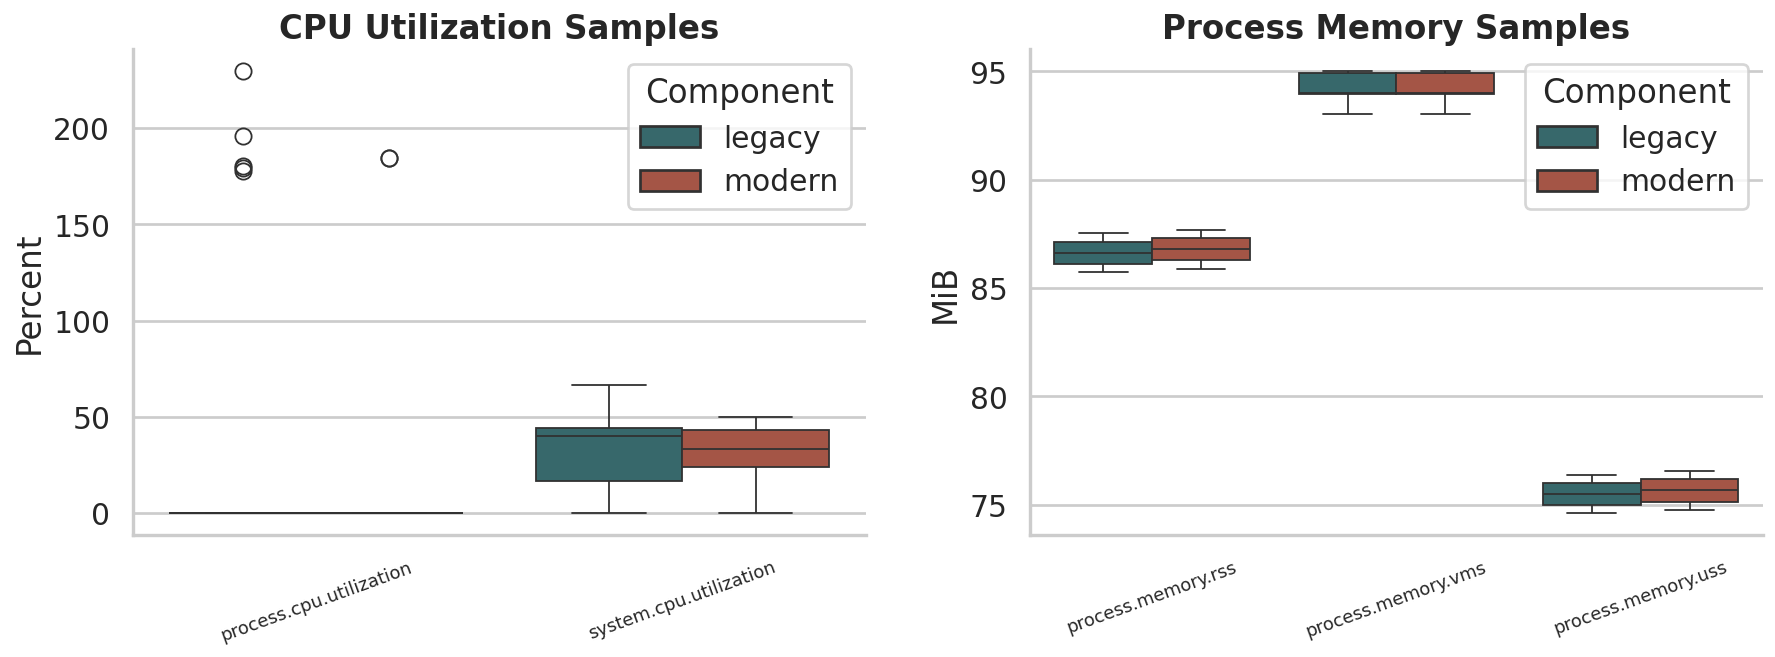

In [18]:
resource_focus = resource_metrics[resource_metrics["name"].isin([
    "process.cpu.utilization",
    "process.memory.rss",
    "process.memory.uss",
    "process.memory.vms",
    "system.cpu.utilization",
    "system.memory.utilization",
])].copy()
resource_focus["value_mb"] = np.where(resource_focus["unit"].eq("bytes"), resource_focus["value"] / 1024 / 1024, resource_focus["value"])

cpu_df = resource_focus[resource_focus["name"].isin(["process.cpu.utilization", "system.cpu.utilization"])]
mem_df = resource_focus[resource_focus["name"].isin(["process.memory.rss", "process.memory.uss", "process.memory.vms"])]

fig, axes = plt.subplots(1, 2, figsize=(14, 5.4))
sns.boxplot(data=cpu_df, x="name", y="value", hue="component", palette={"legacy": "#2f6f73", "modern": "#b44a36"}, ax=axes[0])
axes[0].set_title("CPU Utilization Samples")
axes[0].set_xlabel("")
axes[0].set_ylabel("Percent")
axes[0].tick_params(axis="x", rotation=20, labelsize=10)

sns.boxplot(data=mem_df, x="name", y="value_mb", hue="component", palette={"legacy": "#2f6f73", "modern": "#b44a36"}, ax=axes[1])
axes[1].set_title("Process Memory Samples")
axes[1].set_xlabel("")
axes[1].set_ylabel("MiB")
axes[1].tick_params(axis="x", rotation=20, labelsize=10)
for ax in axes:
    ax.legend(title="Component")
sns.despine()
plt.tight_layout()

In [19]:
resource_summary = (
    resource_focus.groupby(["config", "component", "name", "unit"])
    .agg(samples=("value", "count"), mean=("value", "mean"), p95=("value", lambda s: q(s, .95)), max=("value", "max"))
    .reset_index()
)
for col in ["mean", "p95", "max"]:
    resource_summary[col] = resource_summary[col].round(2)
resource_summary

,config,component,name,unit,samples,mean,p95,max
0,plain-de,legacy,process.cpu.utilization,percent,12,31.24,186.62,195.7
1,plain-de,legacy,process.memory.rss,bytes,12,90812757.33,91721318.40,91725824.0
2,plain-de,legacy,process.memory.uss,bytes,12,79156224.00,80064102.40,80068608.0
3,plain-de,legacy,process.memory.vms,bytes,12,99033088.00,99557376.00,99557376.0
4,plain-de,legacy,system.cpu.utilization,percent,12,35.67,60.59,66.7
5,plain-de,legacy,system.memory.utilization,percent,12,17.60,17.60,17.6
6,plain-de,modern,process.cpu.utilization,percent,12,15.36,82.93,184.3
7,plain-de,modern,process.memory.rss,bytes,12,90991616.00,91908915.20,91922432.0
8,plain-de,modern,process.memory.uss,bytes,12,79334400.00,80251699.20,80265216.0
9,plain-de,modern,process.memory.vms,bytes,12,99033088.00,99557376.00,99557376.0


## Annotator Processing-Time Metrics



,config,component,name,samples,mean_ms,p50_ms,p95_ms,max_ms
0,plain-de,legacy,gazetteer_legacy_processing_ms,6,2.33,2.0,3.0,3.0
1,plain-de,modern,gazetteer_processing_ms,6,2.00,2.0,2.0,2.0
2,virus-skipgram,legacy,gazetteer_legacy_processing_ms,6,2.50,2.5,3.0,3.0
3,virus-skipgram,modern,gazetteer_processing_ms,6,2.33,2.0,3.0,3.0


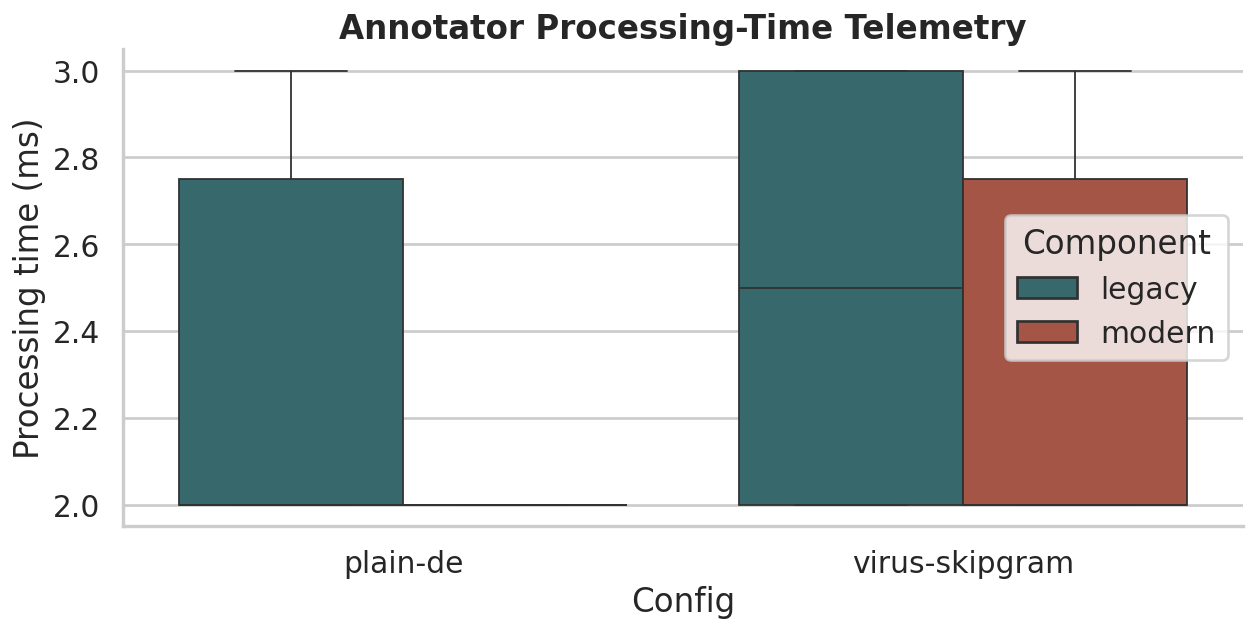

In [20]:
processing_stats = (
    processing_metrics.groupby(["config", "component", "name"])["value"]
    .agg(samples="count", mean_ms="mean", p50_ms="median", p95_ms=lambda s: q(s, .95), max_ms="max")
    .reset_index()
)
for col in ["mean_ms", "p50_ms", "p95_ms", "max_ms"]:
    processing_stats[col] = processing_stats[col].round(2)

fig, ax = plt.subplots(figsize=(10, 5.2))
sns.boxplot(data=processing_metrics, x="config", y="value", hue="component", palette={"legacy": "#2f6f73", "modern": "#b44a36"}, ax=ax)
ax.set_title("Annotator Processing-Time Telemetry")
ax.set_xlabel("Config")
ax.set_ylabel("Processing time (ms)")
ax.legend(title="Component")
sns.despine()
plt.tight_layout()
processing_stats